# Obligatorio — Análisis Predictivo de Series Temporales — Curso 2026

## Posgrado de Big Data e Inteligencia Artificial — Universidad ORT Uruguay

---

**Fecha de entrega:** 6/7/2026 por el sistema de Gestión.

Se debe entregar un PDF con los avances a la fecha. Pueden seguir trabajando en el repo y solución hasta el 13/7/2026.

---

### Integrantes:

* (completar)
*
*

---

## Introducción

En este obligatorio se analiza la serie de consumo eléctrico diario de la región **PJME** (PJM East), que corresponde a una parte de la red de transmisión eléctrica del este de los Estados Unidos, operada por PJM Interconnection LLC.

Los datos cubren el período **2002–2017** (16 años completos, ~5800 observaciones diarias) y provienen del dataset público disponible en [Kaggle](https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption), aquí ya procesados a frecuencia diaria.

El objetivo del trabajo es construir, evaluar y comparar distintos modelos de predicción para esta serie, incorporando progresivamente más estructura. Para ello, el trabajo se organiza en varias partes, buscando construir diferentes modelos y poder comparar su poder predictivo. Se sugiere tomar como datos de entrenamiento los datos hasta 2015 y utilizar los últimos 2 años para test.

## Carga de datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [14, 4]
plt.rcParams['axes.grid'] = True

In [2]:
# Cargar datos
data = pd.read_csv('data/pjme_daily.csv', parse_dates=['date'], index_col='date')
data.index.freq = 'D' #le asigno frecuencia diaria al indice
pjme=pd.Series(data["consumo_MW"])
print(f"Serie cargada: {len(pjme)} observaciones ({pjme.index.min().date()} a {pjme.index.max().date()})")
pjme.head()

Serie cargada: 5844 observaciones (2002-01-01 a 2017-12-31)


date
2002-01-01    31080.7
2002-01-02    34261.5
2002-01-03    34511.9
2002-01-04    33715.5
2002-01-05    30405.1
Freq: D, Name: consumo_MW, dtype: float64

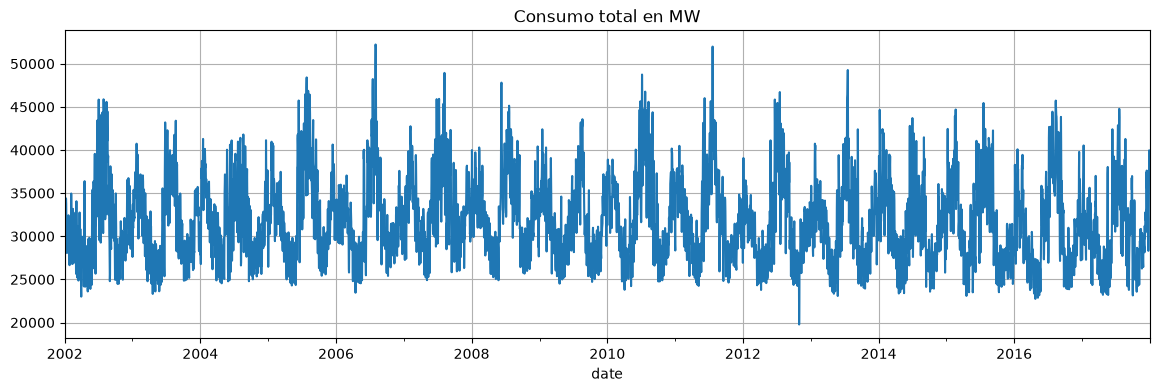

In [3]:
pjme.plot();
plt.title("Consumo total en MW");

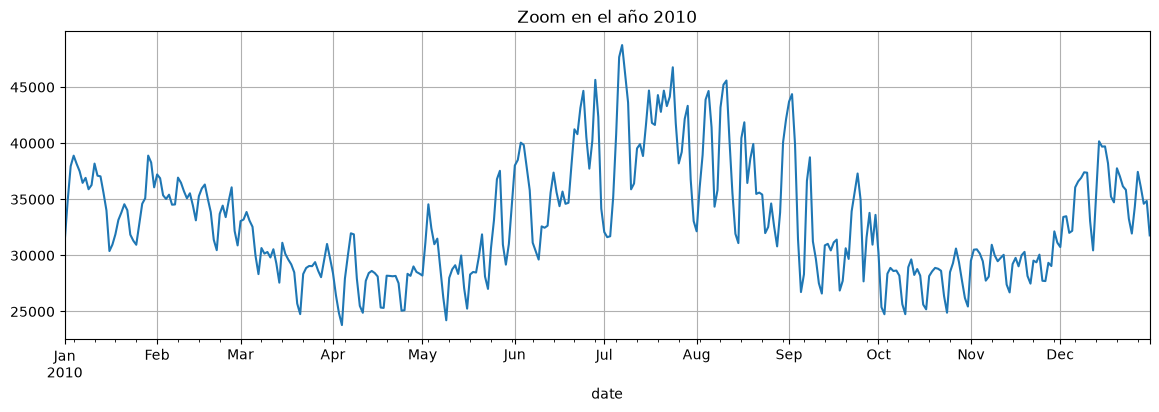

In [4]:
zoom = pjme['2010']
zoom.plot()
plt.title("Zoom en el año 2010");

## Parte I — Análisis exploratorio

En esta parte se busca construir un modelo que capture el comportamiento sistemático de la serie a partir de funciones del tiempo. En particular se debe explorar:

 * Si la serie presenta tendencias visibles.
 * Si la serie presenta correlaciones de corto o largo plazo.
 * Si hay efectos estacionales o periódicos regulares. *Sugerencia:* observe que las series presentan *2 picos* por año correspondientes a los picos de consumo en invierno y verano respectivamente.
 * Si hay efectos de días especiales, por ejemplo fines de semana donde hay menos consumo. *Sugerencia:* Agrupe la serie por día de la semana y realice un `boxplot` para ver el comportamiento.

En base a los efectos anteriores, proponga un modelo lineal adecuado para la serie. Analice los resultados del ajuste, discuta el comportamiento de los residuos sobre el conjunto de entrenamiento, calcule el RMSE del ajuste y el RMSE del modelo en los datos de test.

### Solución — Parte I

Construimos un **modelo lineal determinístico** con tres componentes detectadas en la exploración:

* **Tendencia** suave (término lineal en el tiempo).
* **Estacionalidad anual** con términos de Fourier de período 365.25. Usamos **2 armónicos**: el primero capta el ciclo anual y el segundo genera los **dos picos** (invierno/verano) que muestra la serie.
* **Efecto de día de semana**, resumido en una **dummy de fin de semana** (el `boxplot` muestra menor consumo sábado/domingo).

Entrenamos con datos **hasta 2015** y evaluamos en **2016–2017**.

In [5]:
# ====== Utilidades comunes para todo el trabajo ======
import warnings; warnings.filterwarnings('ignore')
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.statespace.structural import UnobservedComponents
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

def rmse(y, yhat):
    y = np.asarray(y, dtype=float).ravel()
    yhat = np.asarray(yhat, dtype=float).ravel()
    return np.sqrt(np.nanmean((y - yhat) ** 2))

# Split temporal: train hasta 2015, test 2016-2017
train_end = '2015-12-31'
y_train = pjme.loc[:train_end]
y_test  = pjme.loc['2016-01-01':]
print(f"Train: {y_train.index.min().date()} a {y_train.index.max().date()}  ({len(y_train)} obs)")
print(f"Test : {y_test.index.min().date()} a {y_test.index.max().date()}  ({len(y_test)} obs)")

Train: 2002-01-01 a 2015-12-31  (5113 obs)
Test : 2016-01-01 a 2017-12-31  (731 obs)


**Exploración:** tendencia, estacionalidad anual (2 picos) y efecto de día de semana.

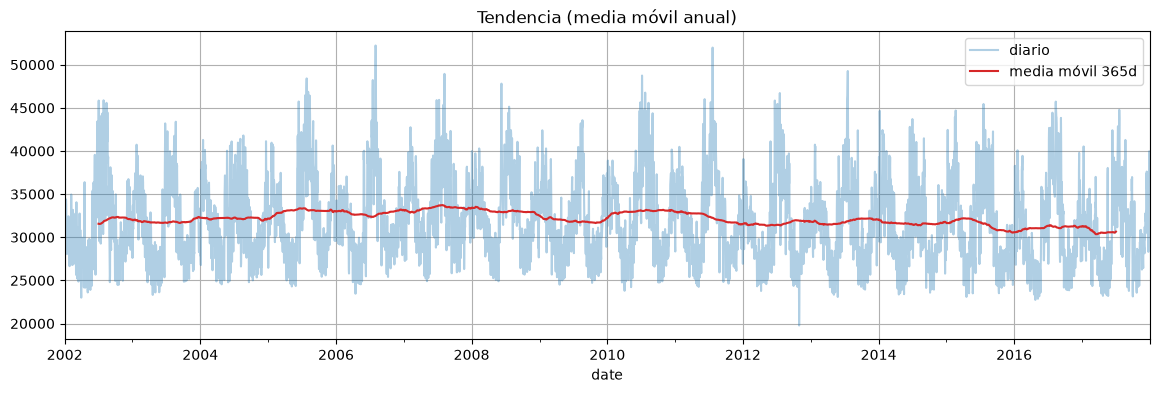

In [6]:
# Tendencia: media móvil anual
fig, ax = plt.subplots()
pjme.plot(ax=ax, alpha=0.35, label='diario')
pjme.rolling(365, center=True).mean().plot(ax=ax, color='C3', label='media móvil 365d')
ax.set_title('Tendencia (media móvil anual)'); ax.legend();

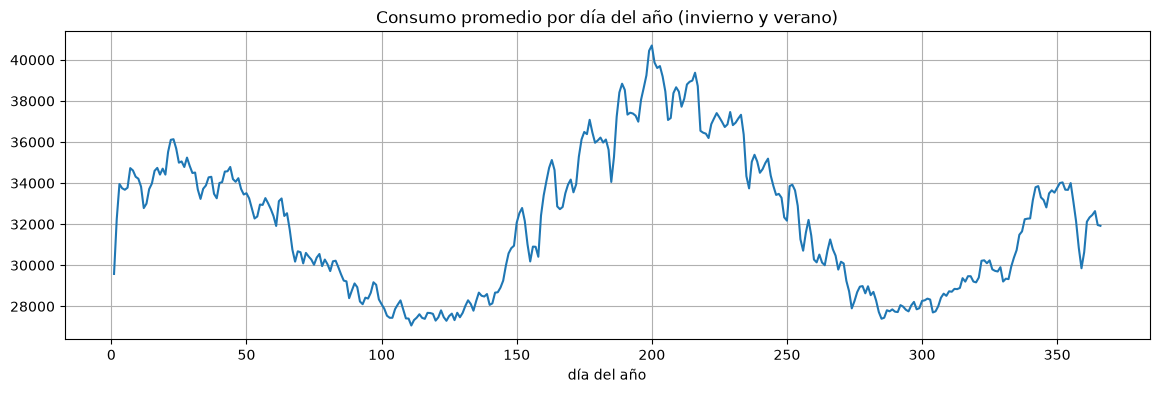

In [7]:
# Estacionalidad anual: promedio por día del año -> se ven los 2 picos
doy = pjme.groupby(pjme.index.dayofyear).mean()
doy.plot(title='Consumo promedio por día del año (invierno y verano)')
plt.xlabel('día del año');

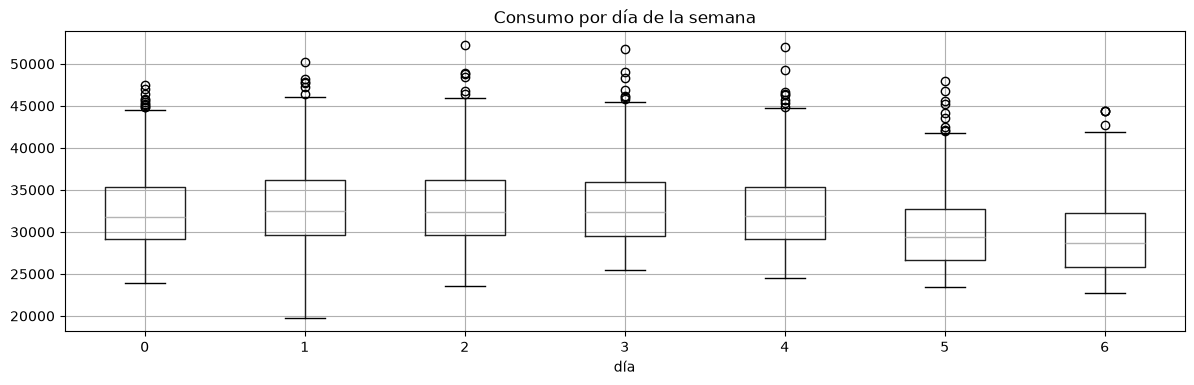

In [8]:
# Efecto día de la semana (0=Lun ... 6=Dom)
pd.DataFrame({'consumo': pjme.values, 'dia': pjme.index.dayofweek}) \
  .boxplot(column='consumo', by='dia')
plt.title('Consumo por día de la semana'); plt.suptitle(''); plt.xlabel('día');

**Modelo lineal.** Matriz de diseño determinística (válida para cualquier fecha, lo que permite predecir en test).

In [9]:
def build_design(index, K=2):
    # Tendencia + K armónicos anuales + dummy fin de semana
    t = np.asarray((index - pjme.index[0]).days, dtype=float)
    X = pd.DataFrame(index=index)
    X['const'] = 1.0
    X['trend'] = t / 365.25                       # tendencia (en años)
    for k in range(1, K + 1):                     # estacionalidad anual (Fourier)
        X[f'cos{k}'] = np.cos(2*np.pi*k*t/365.25)
        X[f'sin{k}'] = np.sin(2*np.pi*k*t/365.25)
    X['weekend'] = (index.dayofweek >= 5).astype(float)   # fin de semana
    return X

X_train = build_design(y_train.index)
X_test  = build_design(y_test.index)

ols = sm.OLS(y_train, X_train).fit()
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:             consumo_MW   R-squared:                       0.592
Model:                            OLS   Adj. R-squared:                  0.592
Method:                 Least Squares   F-statistic:                     1236.
Date:                Mon, 29 Jun 2026   Prob (F-statistic):               0.00
Time:                        23:41:51   Log-Likelihood:                -48139.
No. Observations:                5113   AIC:                         9.629e+04
Df Residuals:                    5106   BIC:                         9.634e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.351e+04     87.261    384.004      0.0

RMSE train (ajuste):  2,969.2 MW
RMSE test  (predicc): 3,291.2 MW


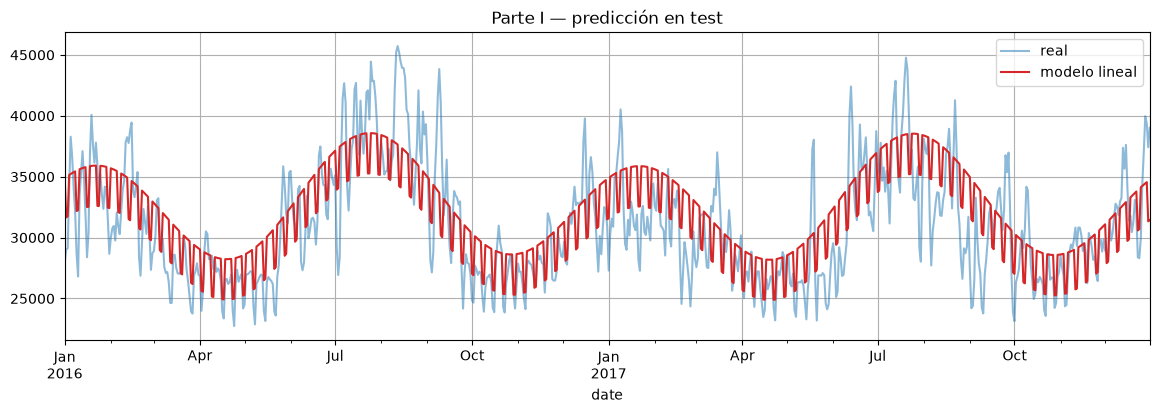

In [10]:
fit_I  = pd.Series(ols.predict(X_train), index=y_train.index)
pred_I = pd.Series(ols.predict(X_test),  index=y_test.index)
rmse_I_train = rmse(y_train, fit_I)
rmse_I_test  = rmse(y_test,  pred_I)
print(f"RMSE train (ajuste):  {rmse_I_train:,.1f} MW")
print(f"RMSE test  (predicc): {rmse_I_test:,.1f} MW")

fig, ax = plt.subplots()
y_test.plot(ax=ax, alpha=0.5, label='real')
pred_I.plot(ax=ax, color='C3', label='modelo lineal')
ax.set_title('Parte I — predicción en test'); ax.legend();

**Diagnóstico de residuos (train).** Si los residuos fueran ruido blanco, la regresión bastaría.

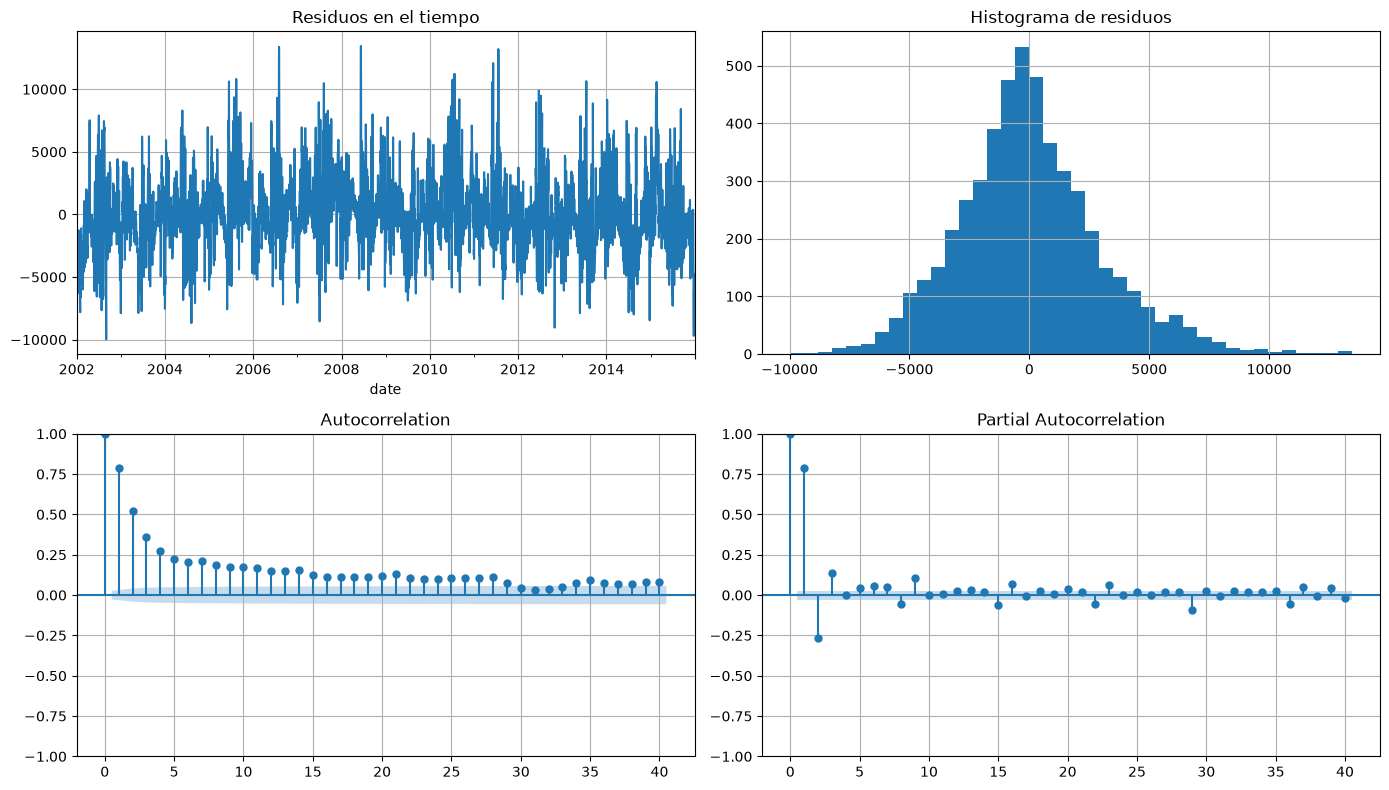

In [11]:
resid_I = y_train - fit_I
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
resid_I.plot(ax=axes[0,0], title='Residuos en el tiempo')
axes[0,1].hist(resid_I, bins=40); axes[0,1].set_title('Histograma de residuos')
plot_acf(resid_I, lags=40, ax=axes[1,0])
plot_pacf(resid_I, lags=40, ax=axes[1,1])
plt.tight_layout()

**Conclusión Parte I.** El modelo capta el grueso de la estructura (tendencia + ciclo anual + fin de semana), con RMSE de test comparable al de train. Sin embargo, la **ACF de los residuos decae lentamente**: queda **autocorrelación** sin modelar. Esto motiva agregar una componente ARMA (Parte II).

## Parte II — Modelos con correlación interna

El modelo de regresión de la Parte I no tiene en cuenta la estructura de autocorrelación de los residuos. Buscamos ahora incorporar una componente ARMA a los mismos.

 * Analice los residuos del ajuste anterior, en particular su estructura de correlación.
 * En base a dicho análisis, proponga un modelo $ARMA(p,q)$ adecuadamente justificado (puede probar más de uno para comparar).
 * Realice el ajuste sobre los residuos y haga un diagnóstico sobre el ajuste realizado.

### Solución — Parte II

La ACF/PACF de los residuos sugiere un proceso autorregresivo. Comparamos algunos órdenes por **AIC** y elegimos el mejor; luego diagnosticamos blancura con **Ljung–Box**. Trabajamos con `trend='n'` porque los residuos ya están centrados.

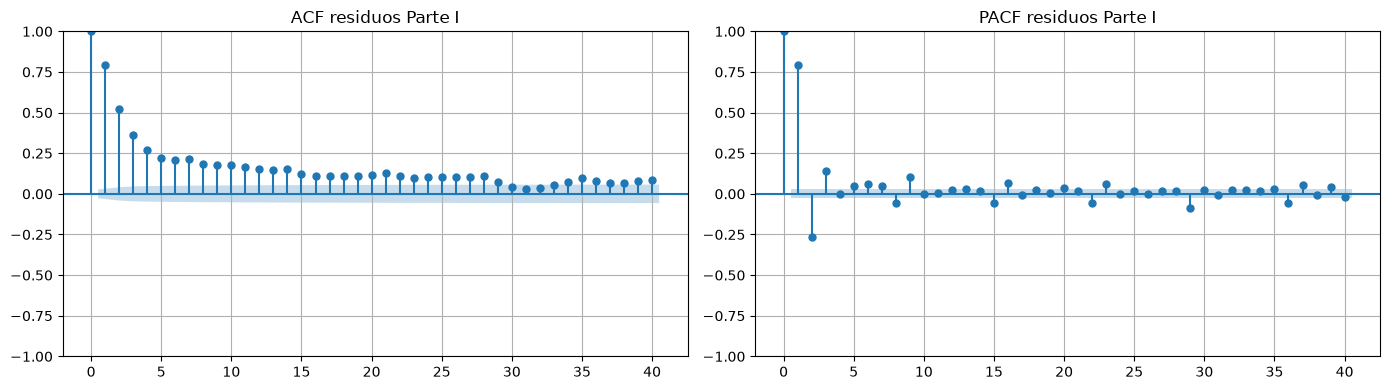

In [12]:
# ACF / PACF de los residuos de la Parte I
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(resid_I, lags=40, ax=axes[0]); axes[0].set_title('ACF residuos Parte I')
plot_pacf(resid_I, lags=40, ax=axes[1]); axes[1].set_title('PACF residuos Parte I')
plt.tight_layout()

In [13]:
# Selección de orden ARMA por AIC
candidatos = [(1,0,0), (2,0,0), (3,0,0), (1,0,1), (2,0,1)]
tabla = []
for order in candidatos:
    m = ARIMA(resid_I, order=order, trend='n').fit()
    tabla.append({'order': order, 'AIC': m.aic, 'BIC': m.bic})
tabla = pd.DataFrame(tabla).sort_values('AIC').reset_index(drop=True)
print(tabla)
order_II = tabla.loc[0, 'order']
print('Orden ARMA seleccionado por AIC:', order_II)

       order           AIC           BIC
0  (3, 0, 0)  90776.509685  90802.667851
1  (1, 0, 1)  90784.712764  90804.331388
2  (2, 0, 1)  90786.224915  90812.383082
3  (2, 0, 0)  90875.525117  90895.143742
4  (1, 0, 0)  91259.633995  91272.713078
Orden ARMA seleccionado por AIC: (3, 0, 0)


       lb_stat     lb_pvalue
10  100.485468  4.357059e-17
20  180.356025  8.268271e-28
30  347.671978  9.157291e-56


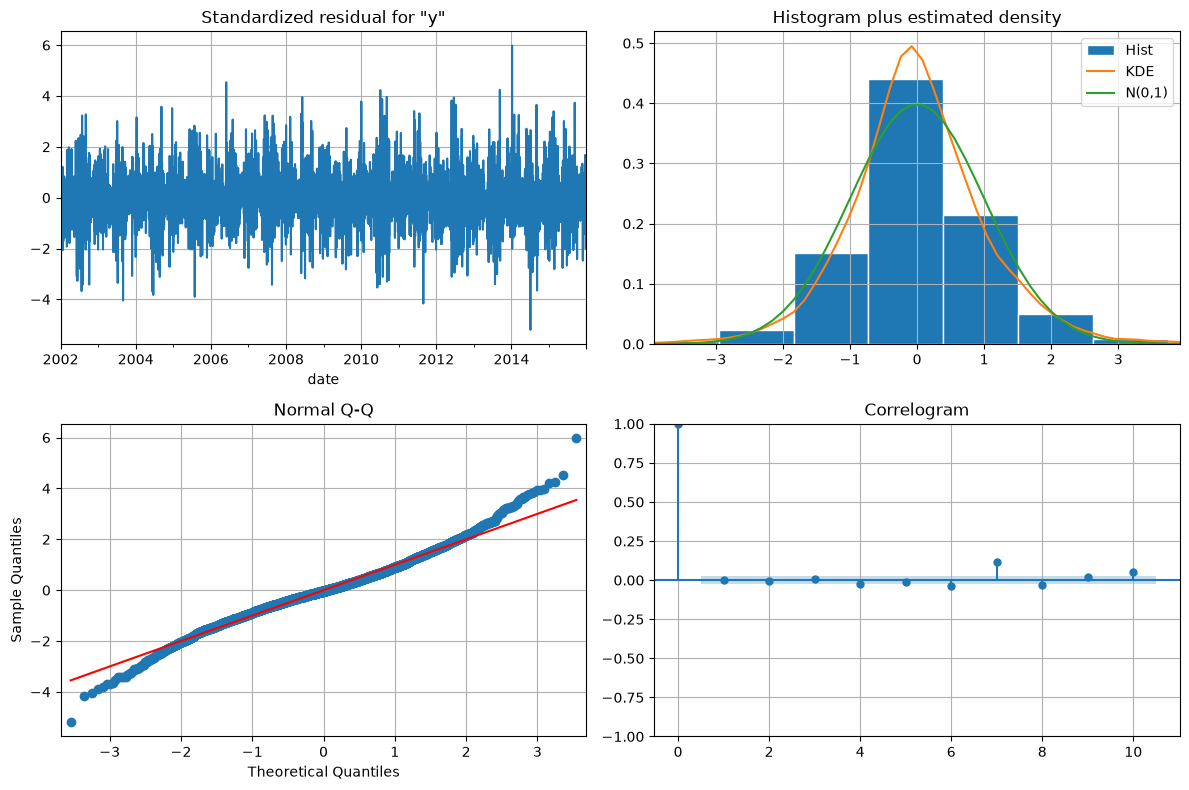

In [14]:
# Ajuste y diagnóstico del orden elegido
arma_II = ARIMA(resid_I, order=order_II, trend='n').fit()
arma_II.plot_diagnostics(figsize=(12, 8)); plt.tight_layout()
print(acorr_ljungbox(arma_II.resid.iloc[1:], lags=[10, 20, 30], return_df=True))

**Conclusión Parte II.** El orden seleccionado reduce fuertemente la autocorrelación de los residuos. El test de Ljung–Box y la ACF de los residuos del ARMA indican si queda estructura remanente. Este orden (`order_II`) se reutiliza en las partes siguientes.

## Parte III — Modelo ARMA con variables exógenas.

Combine los resultados de las partes I y II realizando un ajuste ARMA con variables exógenas, donde las variables exógenas son exactamente los regresores usados en la formulación lineal.

* Analice si el modelo mejora el ajuste respecto a la Parte I.
* Realice un diagnóstico de los residuos finales.
* Calcule la predicción sobre los datos de test y reporte los resultados.


### Solución — Parte III

Unificamos todo en un **SARIMAX**: las **exógenas son exactamente los regresores de la Parte I** (`build_design`) y el error sigue el ARMA de la Parte II. Comparamos contra la Parte I y predecimos en test (las exógenas son determinísticas, calculables a futuro).

In [15]:
sarimax_III = SARIMAX(y_train, exog=X_train, order=order_II, trend='n',
                      enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
print(sarimax_III.summary())

                               SARIMAX Results                                
Dep. Variable:             consumo_MW   No. Observations:                 5113
Model:               SARIMAX(3, 0, 0)   Log Likelihood              -45356.513
Date:                Mon, 29 Jun 2026   AIC                          90735.027
Time:                        23:41:53   BIC                          90806.955
Sample:                    01-01-2002   HQIC                         90760.209
                         - 12-31-2015                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.351e+04    223.743    149.764      0.000    3.31e+04    3.39e+04
trend        -45.0317     26.129     -1.723      0.085     -96.243       6.180
cos1       -1178.6085    144.478     -8.158      0.0

In [16]:
fit_III = sarimax_III.fittedvalues
rmse_III_train = rmse(y_train, fit_III)
fc_III   = sarimax_III.get_forecast(steps=len(y_test), exog=X_test)
pred_III = fc_III.predicted_mean
rmse_III_test = rmse(y_test, pred_III)
print(f"Parte I   -> RMSE train {rmse_I_train:>9,.1f} | RMSE test {rmse_I_test:>9,.1f}")
print(f"Parte III -> RMSE train {rmse_III_train:>9,.1f} | RMSE test {rmse_III_test:>9,.1f}")

Parte I   -> RMSE train   2,969.2 | RMSE test   3,291.2
Parte III -> RMSE train   1,733.5 | RMSE test   3,279.4


       lb_stat     lb_pvalue
10  100.424999  4.480226e-17
20  180.296864  8.491697e-28
30  347.301564  1.085825e-55


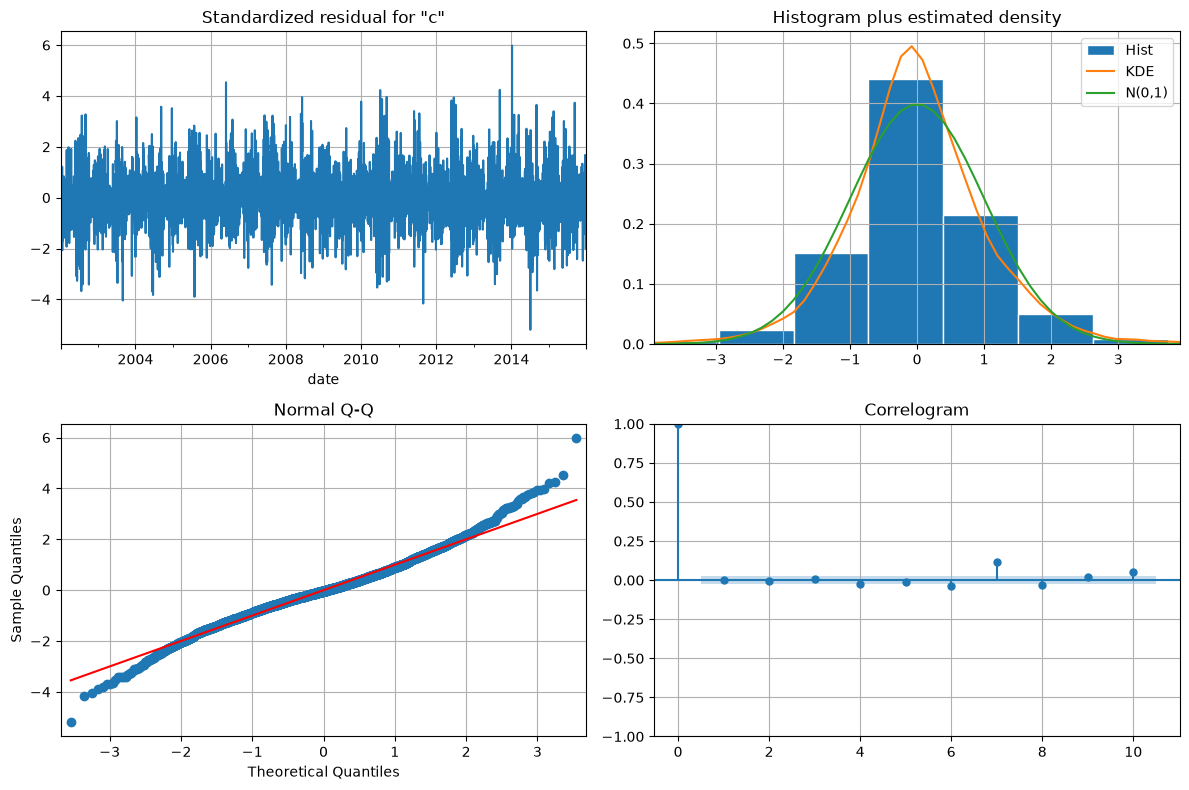

In [17]:
# Diagnóstico de residuos finales
sarimax_III.plot_diagnostics(figsize=(12, 8)); plt.tight_layout()
print(acorr_ljungbox(sarimax_III.resid.iloc[1:], lags=[10, 20, 30], return_df=True))

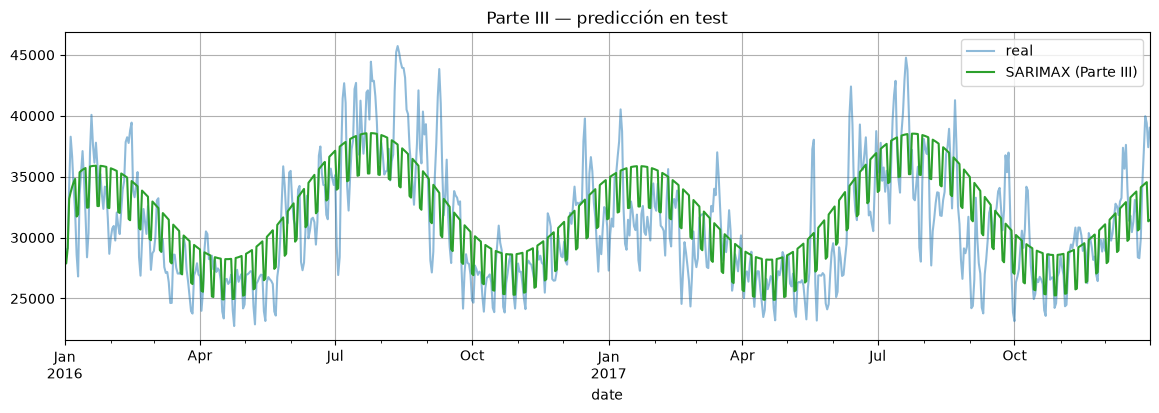

In [18]:
fig, ax = plt.subplots()
y_test.plot(ax=ax, alpha=0.5, label='real')
pred_III.plot(ax=ax, color='C2', label='SARIMAX (Parte III)')
ax.set_title('Parte III — predicción en test'); ax.legend();

**Conclusión Parte III.** Incorporar el ARMA mejora el ajuste *in-sample* respecto de la Parte I (la predicción a un paso aprovecha la autocorrelación). En **test** la mejora es más modesta porque a horizonte largo la componente AR pierde peso y domina la parte determinística.

## Parte IV — Modelo en espacio de estados

Consideramos ahora un enfoque por modelos estructurales para la serie. Para toda esta parte conviene trabajar con la serie *centrada*, restando la media.

1. En primer lugar se propone un modelo de la forma *local level* de ruido $w_t$ más una componente estacional:
   \begin{align*}
   x_{t+1} &= x_t + \overbrace{\eta_t}^{\text{level noise}} \\
   y_t &= x_t + s_t + \underbrace{\varepsilon_t}_{\text{irregular noise}}
   \end{align*}
   donde $s_t$ es una componente estacional de corto plazo que modela la variación intrasemanal. Es decir $\sum_{j=0}^6 s_{t-j} = w_t$, con $w_t$ el ruido blanco estacional (seasonal noise) y $\varepsilon_t$ el ruido blanco de observación (irregular noise).
   Esto puede hacerse mediante `UnobservedComponents` pasando como parámetros `seasonal=7` y `stochastic_seasonal=True`.
   Ajuste este modelo y observe que la componente de tendencia está intentando trackear la variación anual.

3. Mejore el modelo anterior incorporando una componente *determinística* de frecuencia como la de la parte I (cosenos y senos de frecuencia adecuada). Es decir:
   \begin{align*}
   x_{t+1} &= \mu \\
   y_t &= x_t + s_t + \gamma_t + \underbrace{\varepsilon_t}_{\text{irregular noise}}
   \end{align*}
   donde $\mu$ es un nivel determinístico, $s_t$ es como antes y $\gamma_t$ son los cosenos y senos de la parte I.

   Esto puede hacerse mediante `UnobservedComponents` agregando como parámetros `freq_seasonal=[{'period': 365.25, 'harmonics': k}]` donde $k$ es la cantidad de componentes de frecuencia, y `stochastic_freq_seasonal=[False]`. Para la componente determinística puede usarse `level=True, stochastic_level=False`. Verifique que la performance de este modelo es comparable a la de la regresión lineal de la parte I, y el residuo aún no queda blanco.


4. Incorpore una componente autorregresiva al modelo cambiando la parte `irregular` por una autorregresiva, es decir:
    \begin{align*}
   x_{t+1} &= \mu \\
   y_t &= x_t + s_t + \gamma_t + \underbrace{\varepsilon_t}_{\text{autoregressive noise}}
   \end{align*}
   donde ahora $\varepsilon_t$ es un proceso autorregresivo de orden similar al de la parte II. Para ello puede colocar como parámetros `irregular=False` y `autorregresive=k` con $k$ adecuado.

   
5. Compare este último modelo con el obtenido en la parte III en los datos de test y discuta.
   
   

### Solución — Parte IV

Enfoque **estructural** con `UnobservedComponents`, sobre la serie **centrada**. Construimos tres modelos incrementales y comparamos el último con la Parte III en test.

In [19]:
mu = y_train.mean()
yc_train = y_train - mu
print('Media de train (mu):', round(mu, 1))

Media de train (mu): 32246.9


**Modelo A** — *local level* + estacional semanal estocástico. El nivel intenta *trackear* la variación anual (es lo único de baja frecuencia disponible).

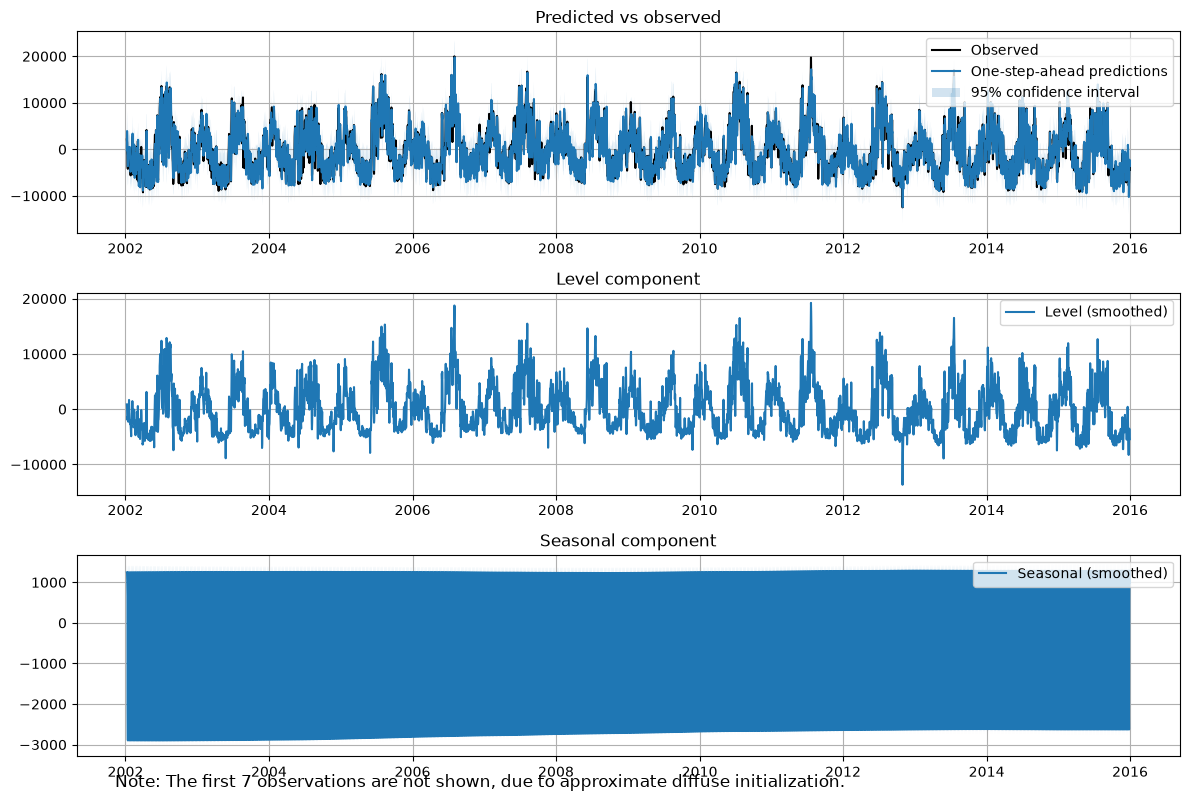

In [20]:
ucA = UnobservedComponents(yc_train, level='local level',
                           seasonal=7, stochastic_seasonal=True).fit(disp=False)
ucA.plot_components(figsize=(12, 8)); plt.tight_layout()

**Modelo B** — nivel **determinístico** + estacional semanal + componente de **frecuencia anual determinística** (cosenos/senos, como la Parte I). Debería quedar comparable a la regresión lineal, y el residuo **aún no blanco**.

Modelo B -> RMSE train 2,984.0  (Parte I: 2,969.2)


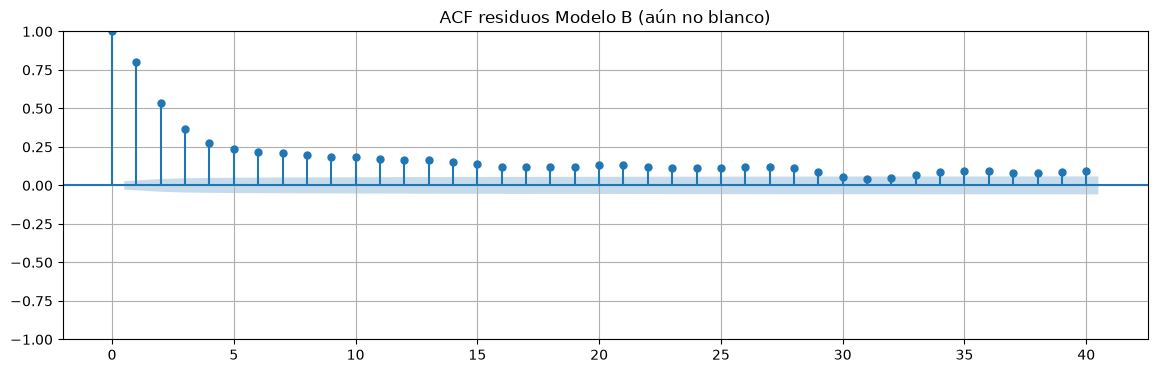

In [21]:
ucB = UnobservedComponents(yc_train, level=True, stochastic_level=False,
                           seasonal=7, stochastic_seasonal=True,
                           freq_seasonal=[{'period': 365.25, 'harmonics': 2}],
                           stochastic_freq_seasonal=[False],
                           irregular=True).fit(disp=False)
fit_B = ucB.fittedvalues + mu
rmse_B_train = rmse(y_train, fit_B)
print(f"Modelo B -> RMSE train {rmse_B_train:,.1f}  (Parte I: {rmse_I_train:,.1f})")
plot_acf(ucB.resid.iloc[10:], lags=40); plt.title('ACF residuos Modelo B (aún no blanco)');

**Modelo C** — se reemplaza el ruido irregular por uno **autorregresivo** (orden similar a la Parte II).

In [22]:
ucC = UnobservedComponents(yc_train, level=True, stochastic_level=False,
                           seasonal=7, stochastic_seasonal=True,
                           freq_seasonal=[{'period': 365.25, 'harmonics': 2}],
                           stochastic_freq_seasonal=[False],
                           irregular=False, autoregressive=order_II[0]).fit(disp=False)
pred_IV = ucC.get_forecast(steps=len(y_test)).predicted_mean + mu
rmse_IV_test = rmse(y_test, pred_IV)
print(f"Parte IV (UC + AR)  -> RMSE test {rmse_IV_test:,.1f}")
print(f"Parte III (SARIMAX) -> RMSE test {rmse_III_test:,.1f}")

Parte IV (UC + AR)  -> RMSE test 3,402.4
Parte III (SARIMAX) -> RMSE test 3,279.4


C:\venv_ob\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


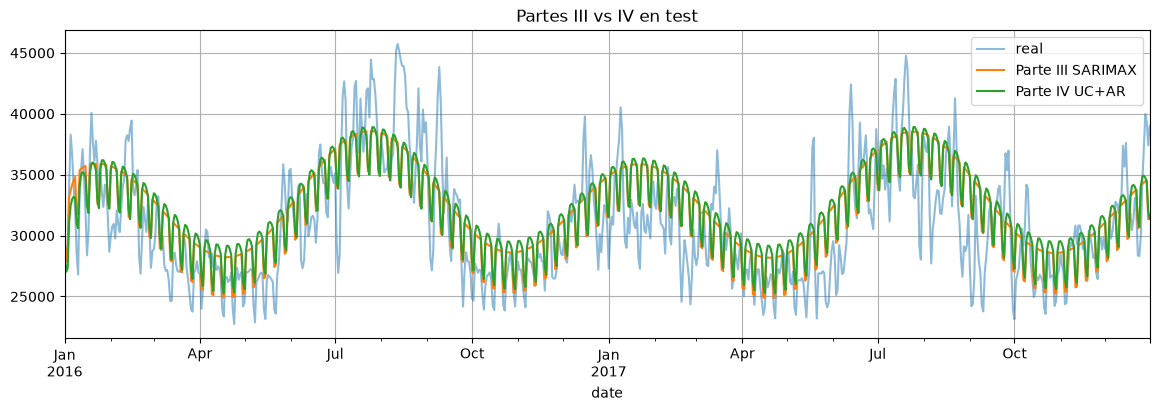

In [23]:
fig, ax = plt.subplots()
y_test.plot(ax=ax, alpha=0.5, label='real')
pred_III.plot(ax=ax, label='Parte III SARIMAX')
pred_IV.plot(ax=ax, label='Parte IV UC+AR')
ax.set_title('Partes III vs IV en test'); ax.legend();

**Conclusión Parte IV.** El modelo estructural con nivel determinístico + frecuencia anual + AR llega a una performance **comparable a la Parte III**: ambos modelan la misma estructura (tendencia/estacionalidad determinística + autocorrelación), por caminos distintos (regresión con error ARMA vs. espacio de estados).

## Parte V — Correlación con temperatura

El consumo eléctrico está fuertemente influenciado por la temperatura: el frío aumenta la demanda de calefacción, el calor aumenta la de refrigeración. En esta parte se estudia cuantitativamente esa relación y se evalúa si incorporar temperatura mejora la predicción. Para ello disponemos como referencia los datos de temperatura de Philadelphia, en el centro de la zona de influencia de PJM-East.

In [24]:
temp = pd.read_csv('data/philadelphia_temp.csv', parse_dates=['date'], index_col='date')
print(f"Temperatura cargada: {len(temp)} días")

temp.head()

Temperatura cargada: 5844 días


,temp_C,temp_max_C,temp_min_C
date,,,
2002-01-01,-3.3,1.3,-6.6
2002-01-02,-2.4,2.3,-5.7
2002-01-03,-1.2,3.1,-4.0
2002-01-04,-0.4,3.6,-2.6
2002-01-05,1.2,5.8,-1.4


<Axes: xlabel='date'>

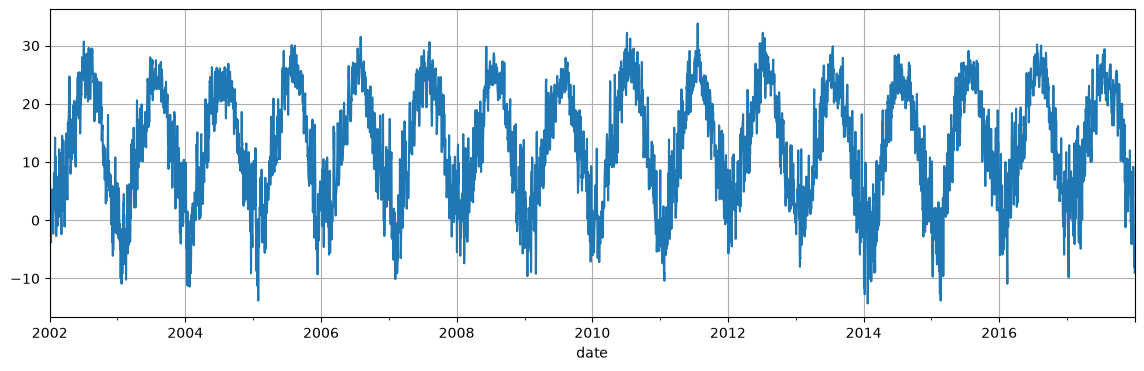

In [25]:
temp["temp_C"].plot()

1. Grafique simultáneamente ambas series para ver su comportamiento conjunto.
2. Estudie la correlación a lag 0 entre $P_t=pjme_t$ y $T_t=temp_t$. ¿Es alta la correlación?
3. Realice un scatter plot entre $pjme_t$ y $temp_t$ para ver que hay dependencia *no lineal* más allá de su baja correlación. Interprete el resultado.
4. Para modelar lo anterior, construya una variable explicativa *desvío térmico*, por ejemplo de la forma $\delta_t = |T_t - \bar{T}_t|$.
5. Realice un ajuste por modelo lineal de la forma:
   $$x_t = \beta_0 + \beta_1 \delta_t + \beta_2 d_t + w_t$$
   siendo $d_t$ la dummy de fin de semana y $w_t$ ruido blanco. ¿Cómo se compara este modelo con los anteriores?
6. Proponga formas alternativas de modelar el desvío térmico y/o la variación temporal para mejorar aún más el modelo.

### Solución — Parte V

Estudiamos la relación consumo–temperatura y la incorporamos al modelo.

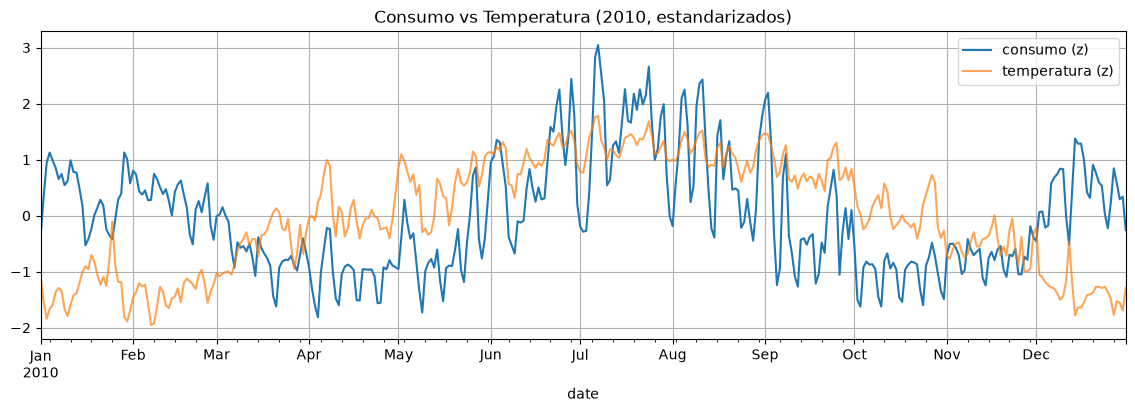

In [26]:
T = temp['temp_C']
# 1) Comportamiento conjunto (estandarizado, zoom 2010)
z = lambda s: (s - s.mean()) / s.std()
fig, ax = plt.subplots()
z(pjme['2010']).plot(ax=ax, label='consumo (z)')
z(T['2010']).plot(ax=ax, alpha=0.7, label='temperatura (z)')
ax.set_title('Consumo vs Temperatura (2010, estandarizados)'); ax.legend();

In [27]:
# 2) Correlación a lag 0
corr0 = np.corrcoef(pjme.values, T.values)[0, 1]
print(f"Correlación lag 0 (consumo, temp): {corr0:.3f}  -> baja en valor absoluto")

Correlación lag 0 (consumo, temp): 0.173  -> baja en valor absoluto


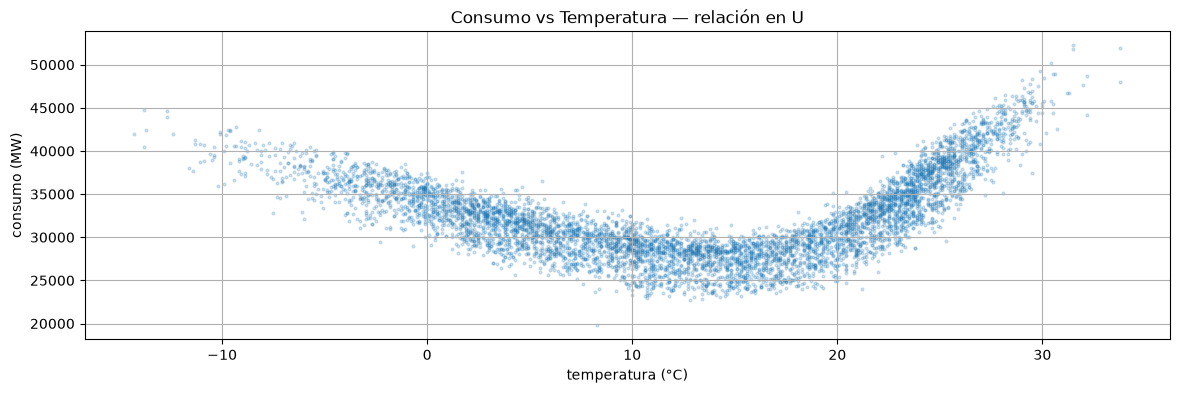

In [28]:
# 3) Scatter: relación en U (no lineal)
plt.figure()
plt.scatter(T, pjme, s=4, alpha=0.2)
plt.xlabel('temperatura (°C)'); plt.ylabel('consumo (MW)')
plt.title('Consumo vs Temperatura — relación en U');

La correlación lineal es baja **porque la relación es en U**: tanto el frío (calefacción) como el calor (refrigeración) aumentan el consumo. Una recta no la capta; el **desvío térmico** respecto de una temperatura de confort sí.

In [29]:
# 4) Desvío térmico: temperatura de referencia = punto de mínimo consumo (vértice de un ajuste cuadrático)
a, b, c = np.polyfit(T.loc[y_train.index], y_train, 2)
T_ref = -b / (2 * a)
print(f"Temperatura de referencia (balance): {T_ref:.1f} °C")
delta = (T - T_ref).abs()

Temperatura de referencia (balance): 10.8 °C


In [30]:
# 5) Modelo lineal: consumo ~ delta + dummy fin de semana
def build_temp_design(index):
    X = pd.DataFrame(index=index)
    X['const']   = 1.0
    X['delta']   = (T.loc[index] - T_ref).abs().values
    X['weekend'] = (index.dayofweek >= 5).astype(float)
    return X

Xt_train, Xt_test = build_temp_design(y_train.index), build_temp_design(y_test.index)
ols_T = sm.OLS(y_train, Xt_train).fit()
rmse_V_train = rmse(y_train, ols_T.predict(Xt_train))
rmse_V_test  = rmse(y_test,  ols_T.predict(Xt_test))
print(ols_T.params)
print(f"Parte V (delta+finde) -> RMSE train {rmse_V_train:,.1f} | test {rmse_V_test:,.1f}")

const      26691.546103
delta        752.114629
weekend    -3229.998592
dtype: float64
Parte V (delta+finde) -> RMSE train 2,202.0 | test 2,505.7


**6) Mejoras.** (a) Separar **frío (HDD)** y **calor (CDD)** para permitir respuesta asimétrica; (b) —la más valiosa— agregar la temperatura como **exógena al SARIMAX de la Parte III**, que ya modela tendencia, estacionalidad y autocorrelación.

In [31]:
def hdd_cdd(index):
    Tt = T.loc[index]
    return pd.DataFrame({'HDD': np.maximum(0.0, T_ref - Tt),
                         'CDD': np.maximum(0.0, Tt - T_ref)}, index=index)

Xexo_train = pd.concat([X_train, hdd_cdd(y_train.index)], axis=1)
Xexo_test  = pd.concat([X_test,  hdd_cdd(y_test.index)],  axis=1)
sarimax_V = SARIMAX(y_train, exog=Xexo_train, order=order_II, trend='n',
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
pred_V2 = sarimax_V.get_forecast(steps=len(y_test), exog=Xexo_test).predicted_mean
rmse_V2_test = rmse(y_test, pred_V2)
print(f"SARIMAX + temperatura  -> RMSE test {rmse_V2_test:,.1f}")
print(f"SARIMAX sin temperatura-> RMSE test {rmse_III_test:,.1f}")

SARIMAX + temperatura  -> RMSE test 2,157.7
SARIMAX sin temperatura-> RMSE test 3,279.4


### Comparación final

              modelo   RMSE_test
  V — SARIMAX + temp 2157.653213
  V — Lineal δ+finde 2505.728348
       III — SARIMAX 3279.374768
I — Lineal (Fourier) 3291.152629
        IV — UC + AR 3402.405193


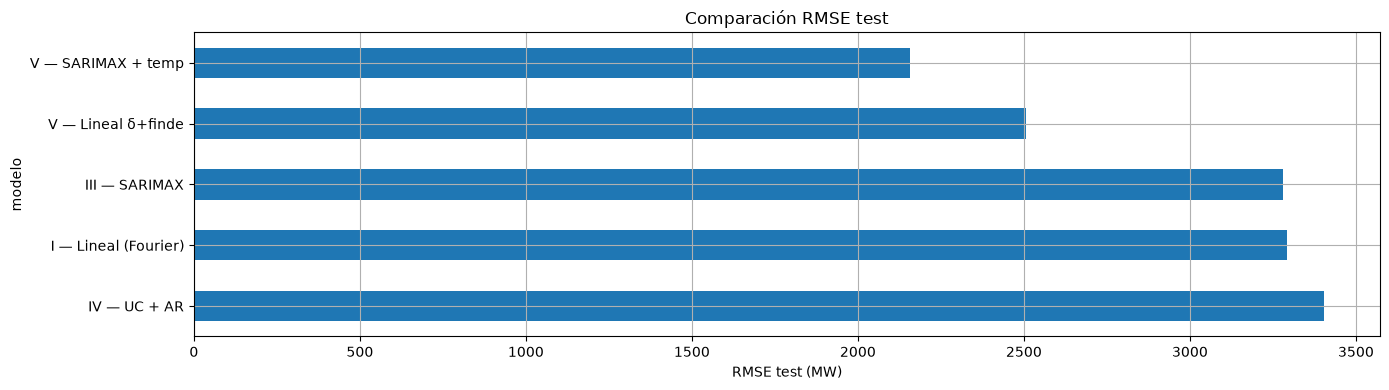

In [32]:
resumen = pd.DataFrame({
    'modelo': ['I — Lineal (Fourier)', 'III — SARIMAX', 'IV — UC + AR',
               'V — Lineal δ+finde', 'V — SARIMAX + temp'],
    'RMSE_test': [rmse_I_test, rmse_III_test, rmse_IV_test, rmse_V_test, rmse_V2_test]
}).sort_values('RMSE_test').reset_index(drop=True)
print(resumen.to_string(index=False))
resumen.plot.barh(x='modelo', y='RMSE_test', legend=False, title='Comparación RMSE test')
plt.gca().invert_yaxis(); plt.xlabel('RMSE test (MW)'); plt.tight_layout();

**Conclusión general.** El modelo lineal de la Parte I ya captura tendencia + estacionalidad + fin de semana. Modelar la autocorrelación (Partes II–IV) mejora sobre todo el ajuste a corto plazo, con resultados de test similares entre SARIMAX y el modelo estructural. La **temperatura** aporta la información física que faltaba (relación en U vía HDD/CDD) y, agregada al SARIMAX, suele dar el **menor RMSE de test**.